In [21]:
import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import pandas as pd
load_dotenv()

PCODES = ['NG008008', 'NG008015', 'NG008019', 'NG008025']

In [22]:
# Selected LGAs in Borno state
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)
gdf_lga_sel = gdf_lga_sel[gdf_lga_sel["ADM2_PCODE"].isin(PCODES)]
# IMERG data
df_imerg = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/imerg/imerg_hfr_lgas_borno.parquet")
df_imerg = df_imerg[df_imerg["pcode"].isin(PCODES)]
# Floodscan data
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")
df_floodscan = df_floodscan[df_floodscan["pcode"].isin(PCODES)]
# 3-day rolling average of SFED per LGA to smooth noise
df_floodscan = df_floodscan.sort_values(["pcode", "valid_date"]).reset_index(drop=True)
df_floodscan["mean"] = df_floodscan.groupby("pcode")["mean"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

Filter to only the LGAs in focus

In [23]:
df_imerg

,iso3,pcode,valid_date,adm_level,mean,median,min,max,count,sum,std
1,NGA,NG008025,2014-01-05,2,0.000000,0.0,0.0,0.000,49,0.000,0.000000
2,NGA,NG008008,2014-01-11,2,0.000000,0.0,0.0,0.000,61,0.000,0.000000
4,NGA,NG008008,2014-02-26,2,0.000000,0.0,0.0,0.000,61,0.000,0.000000
6,NGA,NG008008,2014-03-08,2,0.000000,0.0,0.0,0.000,61,0.000,0.000000
7,NGA,NG008019,2014-06-21,2,0.000000,0.0,0.0,0.000,93,0.000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
165374,NGA,NG008008,2026-04-20,2,0.000000,0.0,0.0,0.000,61,0.000,0.000000
165380,NGA,NG008015,2026-04-20,2,0.000000,0.0,0.0,0.000,65,0.000,0.000000
165384,NGA,NG008015,2026-04-21,2,0.000154,0.0,0.0,0.005,65,0.010,0.000863
165386,NGA,NG008019,2026-04-21,2,0.028441,0.0,0.0,0.305,93,2.645,0.068266


## Optimal rainfall accumulation window

Compute Pearson correlation between rolling cumulative IMERG rainfall (window ends the day before the Floodscan date) and daily Floodscan SFED, for windows of 3, 5, 7, 10, and 14 days. Uses the full daily time series per LGA.

window,3,5,7,10,14,21,28
lga,,,,,,,
Dikwa,0.412,0.481,0.514,0.536,0.553,0.563,0.566
Kala/Balge,0.446,0.513,0.545,0.567,0.583,0.593,0.591
Mafa,0.407,0.470,0.496,0.510,0.513,0.500,0.484
Ngala,0.495,0.568,0.598,0.617,0.626,0.616,0.596


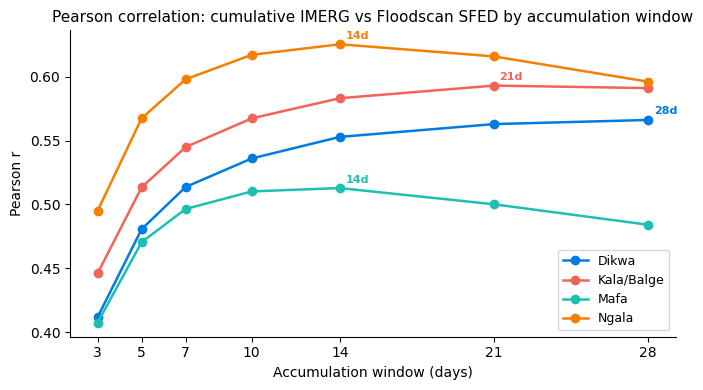

In [24]:
from scipy import stats as scipy_stats
import numpy as np

WINDOWS = [3, 5, 7, 10, 14, 21, 28]

# Prepare daily series
df_fs = df_floodscan.copy()
df_fs["date"] = pd.to_datetime(df_fs["valid_date"]).dt.normalize()
df_fs = df_fs.rename(columns={"mean": "sfed"})

df_pr = df_imerg.copy()
df_pr["date"] = pd.to_datetime(df_pr["valid_date"]).dt.normalize()
df_pr = df_pr.rename(columns={"mean": "precip"}).sort_values(["pcode", "date"])

# Compute rolling cumulative for each window
for w in WINDOWS:
    df_pr[f"precip_{w}d"] = df_pr.groupby("pcode")["precip"].transform(
        lambda x, w=w: x.rolling(w, min_periods=w).sum().shift(1)
    )

# Pearson r per window per LGA
records = []
for pcode in PCODES:
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    df_s = df_fs[df_fs["pcode"] == pcode][["date", "sfed"]]
    df_p = df_pr[df_pr["pcode"] == pcode][["date"] + [f"precip_{w}d" for w in WINDOWS]]
    df_merged = df_p.merge(df_s, on="date").dropna()

    for w in WINDOWS:
        r, p = scipy_stats.pearsonr(df_merged[f"precip_{w}d"], df_merged["sfed"])
        records.append({"pcode": pcode, "lga": lga, "window": w, "r": r, "p": p, "n": len(df_merged)})

df_window_corr = pd.DataFrame(records)

# Line plot: one line per LGA
LGA_COLORS = ["#007CE0", "#F2645A", "#1EBFB3", "#F77F00"]

fig, ax = plt.subplots(figsize=(7, 4))
for pcode, color in zip(PCODES, LGA_COLORS):
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    sub = df_window_corr[df_window_corr["pcode"] == pcode].sort_values("window")
    ax.plot(sub["window"], sub["r"], marker="o", color=color, linewidth=1.8, markersize=6, label=lga)

    # Label the window with highest correlation
    best = sub.loc[sub["r"].idxmax()]
    ax.annotate(
        f"{int(best['window'])}d",
        xy=(best["window"], best["r"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        color=color,
        fontweight="bold",
    )

ax.set_xlabel("Accumulation window (days)", fontsize=10)
ax.set_ylabel("Pearson r", fontsize=10)
ax.set_xticks(WINDOWS)
ax.set_title("Pearson correlation: cumulative IMERG vs Floodscan SFED by accumulation window", fontsize=11)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/pearson_correlation_windows.png", dpi=300)

# Summary table
df_window_corr.pivot(index="lga", columns="window", values="r").round(3)


## Return period thresholds

Calculate the 1-in-3 year return period threshold for Floodscan SFED per LGA using empirical annual maxima. The threshold is interpolated from the ranked annual max series.

In [25]:
from src.utils import rp_calc
import numpy as np

# Prepare daily series with dates normalised
df_fs = df_floodscan.copy()
df_fs["date"] = pd.to_datetime(df_fs["valid_date"]).dt.normalize()
df_fs = df_fs.rename(columns={"mean": "sfed"})

df_pr = df_imerg.copy()
df_pr["date"] = pd.to_datetime(df_pr["valid_date"]).dt.normalize()
df_pr = df_pr.rename(columns={"mean": "precip"}).sort_values(["pcode", "date"])
# 10-day cumulative preceding the current day (window ends day before)
df_pr["precip_10d"] = df_pr.groupby("pcode")["precip"].transform(
    lambda x: x.rolling(10, min_periods=1).sum().shift(1)
)

# Annual max SFED per LGA (exclude current year)
df_fs["year"] = df_fs["date"].dt.year
df_fs_max = (
    df_fs[df_fs["year"] < 2026]
    .groupby(["pcode", "year"])["sfed"]
    .max()
    .reset_index()
)

# Empirical RP for each annual max
df_fs_rp_all = rp_calc.calculate_groups_rp(df_fs_max, by=["pcode"], col_name="sfed", ascending=False)

THRESHOLD_RP = 3

thresholds = {}
for pcode in PCODES:
    sub = (
        df_fs_rp_all[df_fs_rp_all["pcode"] == pcode]
        .dropna(subset=["sfed", "sfed_rp"])
        .sort_values("sfed_rp")
    )
    if sub.empty or sub["sfed_rp"].max() < THRESHOLD_RP:
        thresholds[pcode] = float(sub["sfed"].max()) if not sub.empty else 0.0
    else:
        thresholds[pcode] = float(np.interp(THRESHOLD_RP, sub["sfed_rp"], sub["sfed"]))

pd.DataFrame([
    {
        "pcode": p,
        "lga": gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == p, "ADM2_EN"].iloc[0],
        "rp3_threshold": round(thresholds[p], 5),
    }
    for p in PCODES
])

,pcode,lga,rp3_threshold
0,NG008008,Dikwa,0.07054
1,NG008015,Kala/Balge,0.18966
2,NG008019,Mafa,0.06598
3,NG008025,Ngala,0.19364


## Flood event identification

Events are loaded from `floodscan_rp3_events.parquet`, produced by `00_flood_events.ipynb`. That notebook applies a 3-day rolling average to Floodscan SFED, computes RP-3 thresholds from empirical annual maxima (June–November, 1998–2025), and merges exceedance periods separated by ≤ 7 days into a single event.

In [26]:
# Load flood events from the central parquet (defined in 00_flood_events.ipynb)
df_events = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan_rp3_events.parquet"
)

# Reconstruct thresholds dict (RP-3 per LGA) from the parquet
thresholds = df_events.drop_duplicates("pcode").set_index("pcode")["sfed_thresh"].to_dict()

print(f"Loaded {len(df_events)} events exceeding RP-{THRESHOLD_RP} threshold")
df_events[["lga", "year", "event_start", "event_end", "peak_date", "peak_sfed"]]

Loaded 39 events exceeding RP-3 threshold


,lga,year,event_start,event_end,peak_date,peak_sfed
0,Dikwa,1998,1998-07-25,1998-08-18,1998-08-10,0.121674
1,Dikwa,1998,1998-09-07,1998-09-13,1998-09-10,0.082274
2,Dikwa,2007,2007-07-29,2007-09-25,2007-08-15,0.119825
3,Dikwa,2009,2009-07-28,2009-07-29,2009-07-28,0.083335
4,Dikwa,2010,2010-07-25,2010-09-18,2010-08-15,0.143514
5,Dikwa,2012,2012-06-28,2012-06-28,2012-06-28,0.083963
6,Dikwa,2012,2012-09-06,2012-09-26,2012-09-22,0.092664
7,Dikwa,2014,2014-07-09,2014-09-12,2014-08-12,0.177331
8,Dikwa,2015,2015-06-24,2015-06-25,2015-06-24,0.077397
9,Dikwa,2018,2018-07-18,2018-07-20,2018-07-19,0.110250


## Time series per flood event

Per LGA, plot each RP-3 event with the 14-day preceding window. Blue fill = Floodscan SFED (left axis). Blue bars = 10-day cumulative IMERG (right axis). Dashed red line = RP-3 threshold. Yellow shading = 14-day window before event onset.

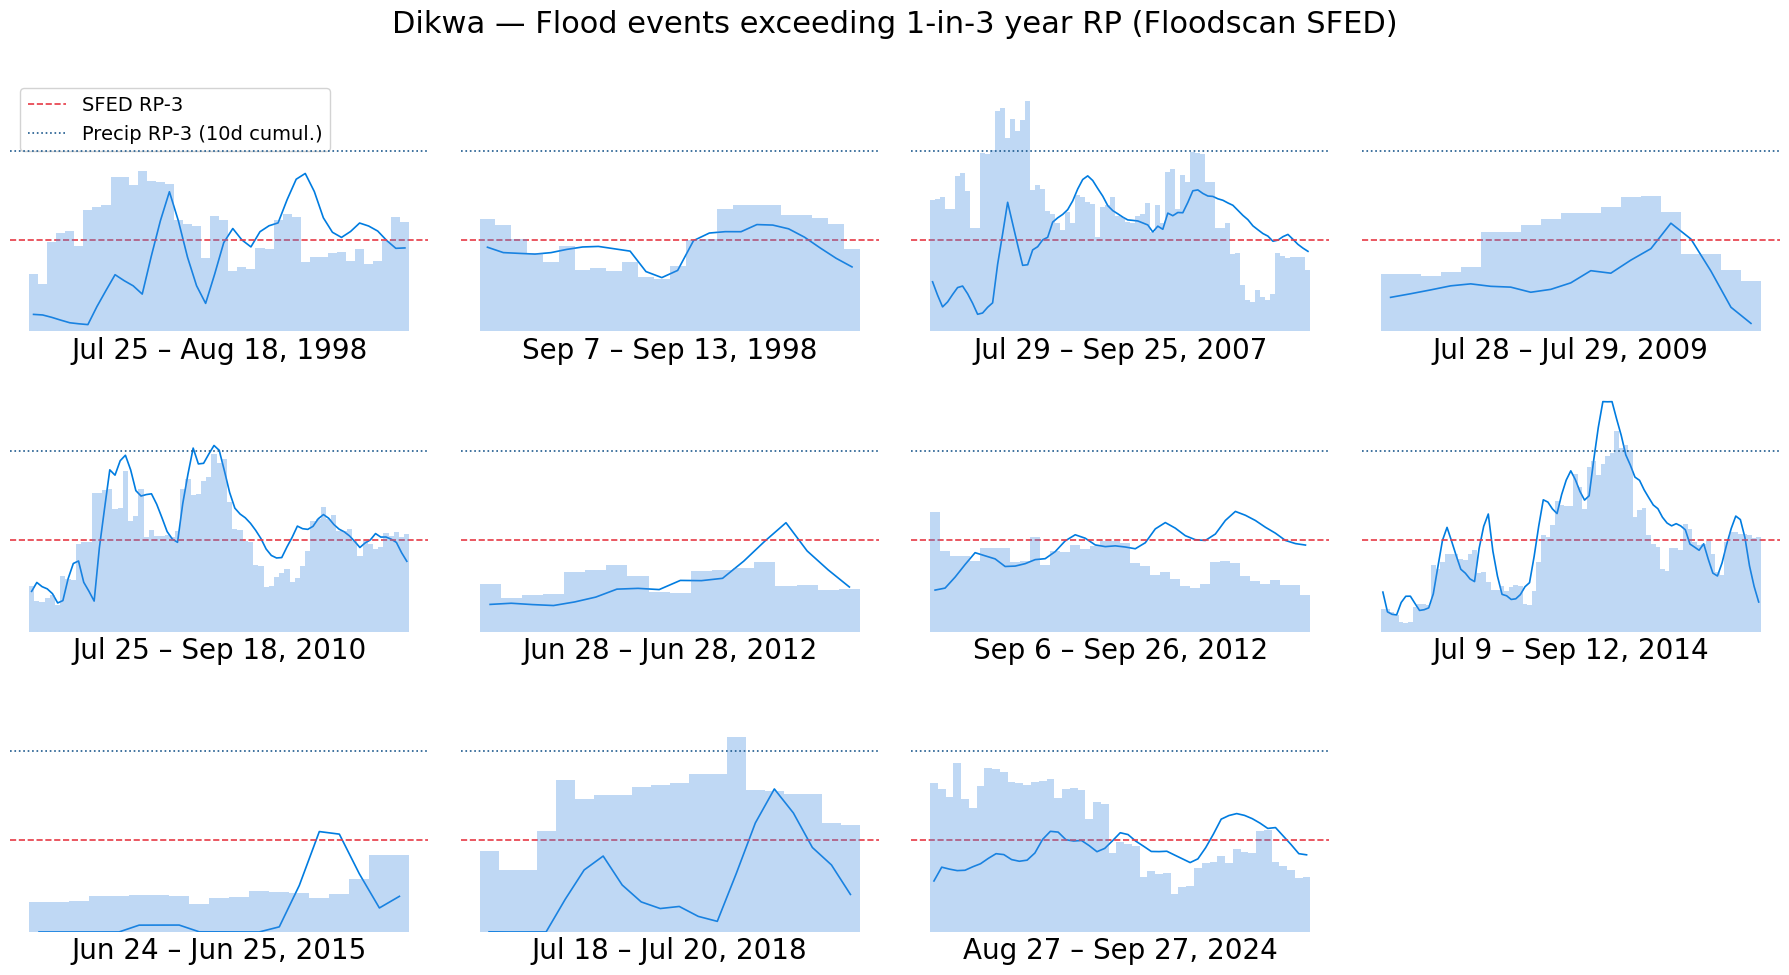

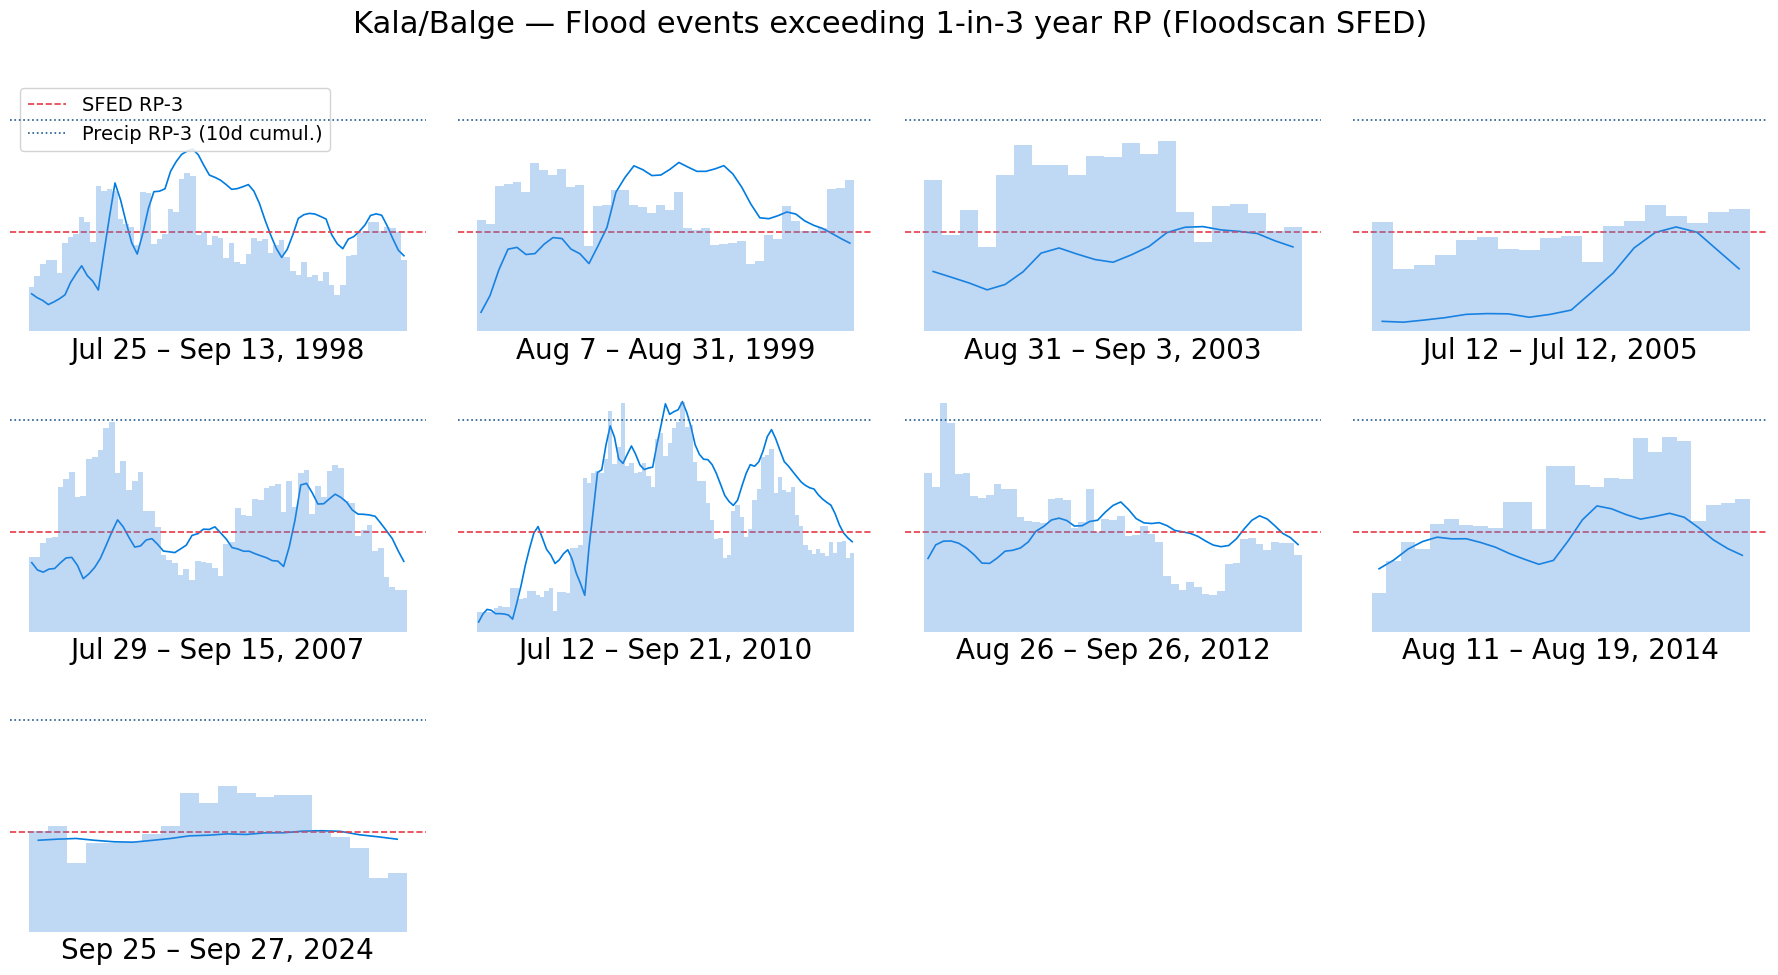

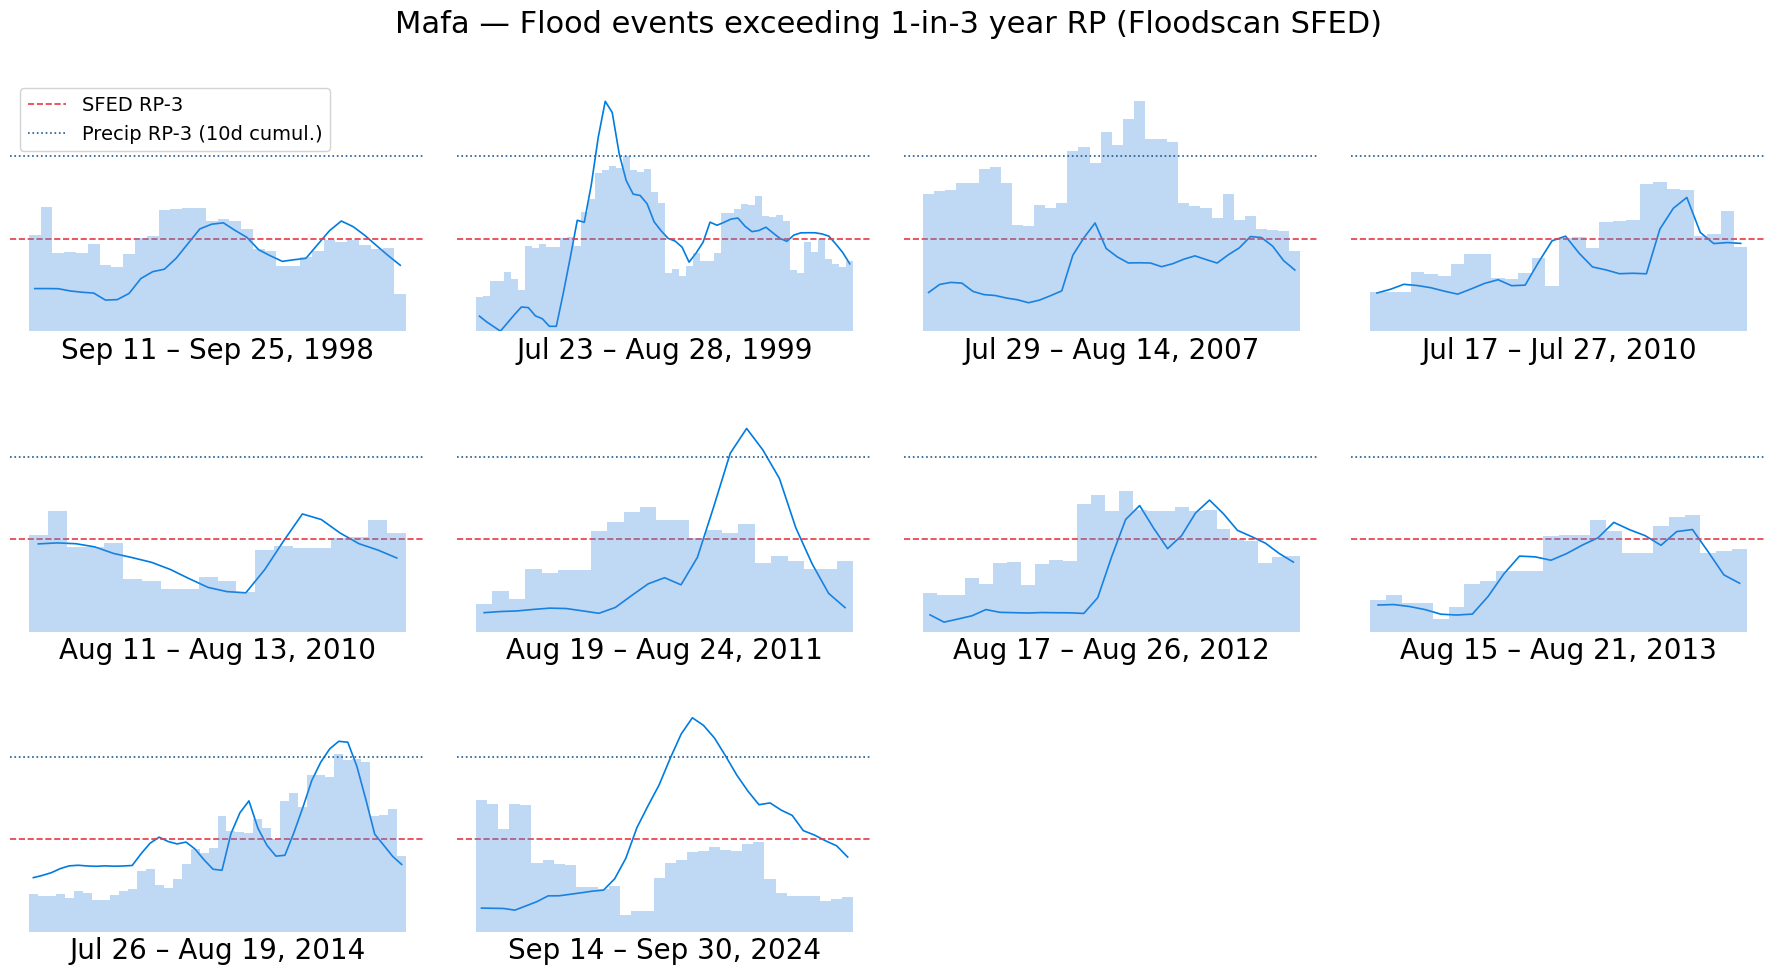

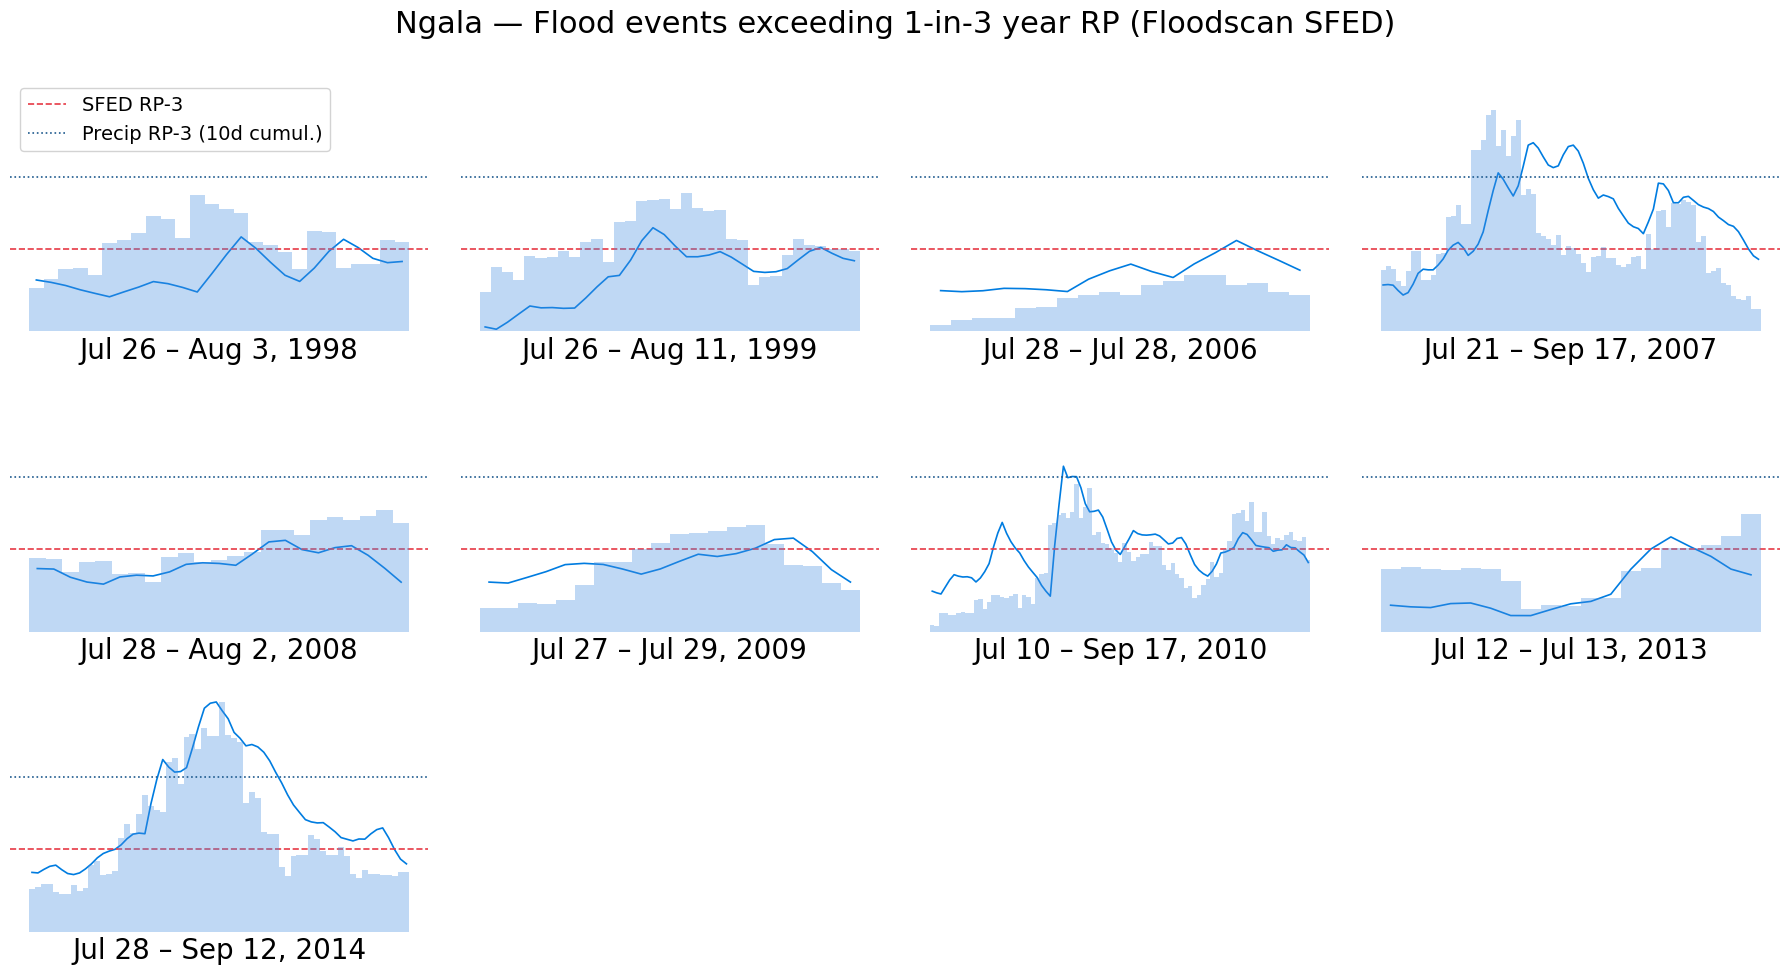

In [27]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

PRE_DAYS = 14
POST_DAYS = 3
FLOOD_MONTHS = range(6, 12)

# 3-year RP threshold for 10-day cumulative precip per LGA
_pr_am = (
    df_pr[df_pr["date"].dt.month.isin(FLOOD_MONTHS) & (df_pr["date"].dt.year < 2026)]
    .copy()
)
_pr_am["year"] = _pr_am["date"].dt.year
_pr_annmax = (
    _pr_am.groupby(["pcode", "year"])["precip_10d"]
    .max().reset_index(name="precip_10d_max").dropna()
)
_pr_rp_all = rp_calc.calculate_groups_rp(
    _pr_annmax, by=["pcode"], col_name="precip_10d_max", ascending=False
)
pr_thresholds_rp3 = {}
for pcode in PCODES:
    sub = (
        _pr_rp_all[_pr_rp_all["pcode"] == pcode]
        .dropna(subset=["precip_10d_max", "precip_10d_max_rp"])
        .sort_values("precip_10d_max_rp")
    )
    pr_thresholds_rp3[pcode] = float(
        np.interp(3, sub["precip_10d_max_rp"], sub["precip_10d_max"])
        if sub["precip_10d_max_rp"].max() >= 3
        else sub["precip_10d_max"].max()
    )

legend_handles = [
    Line2D([0], [0], color="#E63946", linewidth=1.2, linestyle="--", label=f"SFED RP-{THRESHOLD_RP}"),
    Line2D([0], [0], color="#1E5A8E", linewidth=1.2, linestyle=":",  label=f"Precip RP-{THRESHOLD_RP} (10d cumul.)"),
]

for pcode in PCODES:
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    thresh = thresholds[pcode]
    ev = df_events[df_events["pcode"] == pcode].reset_index(drop=True)

    if ev.empty:
        print(f"No events above RP-{THRESHOLD_RP} threshold for {lga}")
        continue

    df_sfed_lga = df_fs[df_fs["pcode"] == pcode][["date", "sfed"]].sort_values("date").set_index("date")
    df_prec_lga = df_pr[df_pr["pcode"] == pcode][["date", "precip_10d"]].sort_values("date").set_index("date")

    sfed_ymax, prec_ymax = 0.0, 0.0
    for _, event in ev.iterrows():
        w_start = event["event_start"] - pd.Timedelta(days=PRE_DAYS)
        w_end = event["event_end"] + pd.Timedelta(days=POST_DAYS)
        sfed_win = df_sfed_lga.loc[w_start:w_end, "sfed"]
        prec_win = df_prec_lga.loc[w_start:w_end, "precip_10d"]
        if not sfed_win.empty:
            sfed_ymax = max(sfed_ymax, sfed_win.max())
        if not prec_win.empty and prec_win.notna().any():
            prec_ymax = max(prec_ymax, prec_win.max())
    sfed_ymax *= 1.1
    prec_ymax = max(prec_ymax * 1.1, pr_thresholds_rp3[pcode] * 1.1, 1.0)

    n = len(ev)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.2), squeeze=False)

    for i, (_, event) in enumerate(ev.iterrows()):
        ax = axes[i // ncols, i % ncols]
        ax2 = ax.twinx()

        w_start = event["event_start"] - pd.Timedelta(days=PRE_DAYS)
        w_end = event["event_end"] + pd.Timedelta(days=POST_DAYS)

        sfed_win = df_sfed_lga.loc[w_start:w_end, "sfed"]
        prec_win = df_prec_lga.loc[w_start:w_end, "precip_10d"]

        ax2.bar(prec_win.index, prec_win.values, color="#4A90E2", alpha=0.35, width=1.0, zorder=1)
        ax2.axhline(pr_thresholds_rp3[pcode], color="#1E5A8E", linewidth=1.2, linestyle=":", zorder=3)
        ax2.set_ylim(0, prec_ymax)
        ax2.yaxis.set_visible(False)
        ax2.xaxis.set_visible(False)
        for spine in ax2.spines.values():
            spine.set_visible(False)

        ax.plot(sfed_win.index, sfed_win.values, color="#007CE0", linewidth=1.2, zorder=2)
        ax.axhline(thresh, color="#E63946", linewidth=1.2, linestyle="--", zorder=3)
        ax.set_ylim(0, sfed_ymax)
        ax.yaxis.set_visible(False)
        ax.xaxis.set_visible(False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        date_label = (
            f"{event['event_start'].strftime('%b %-d')} – "
            f"{event['event_end'].strftime('%b %-d, %Y')}"
        )
        ax.text(0.5, -0.02, date_label, transform=ax.transAxes,
                ha="center", va="top", fontsize=20)

    axes[0, 0].legend(handles=legend_handles, fontsize=14, loc="upper left", framealpha=0.85)

    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)

    fig.suptitle(
        f"{lga} — Flood events exceeding 1-in-{THRESHOLD_RP} year RP (Floodscan SFED)",
        fontsize=22, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(f"figures/flood_events_{pcode}.png", dpi=300)

## Per-event correlation: cumulative rainfall vs flood extent

For each exceedance event, compute Pearson r between 10-day cumulative IMERG and Floodscan SFED across the event window (14-day preceding + event duration). Axes are normalised per LGA so event magnitudes are comparable.

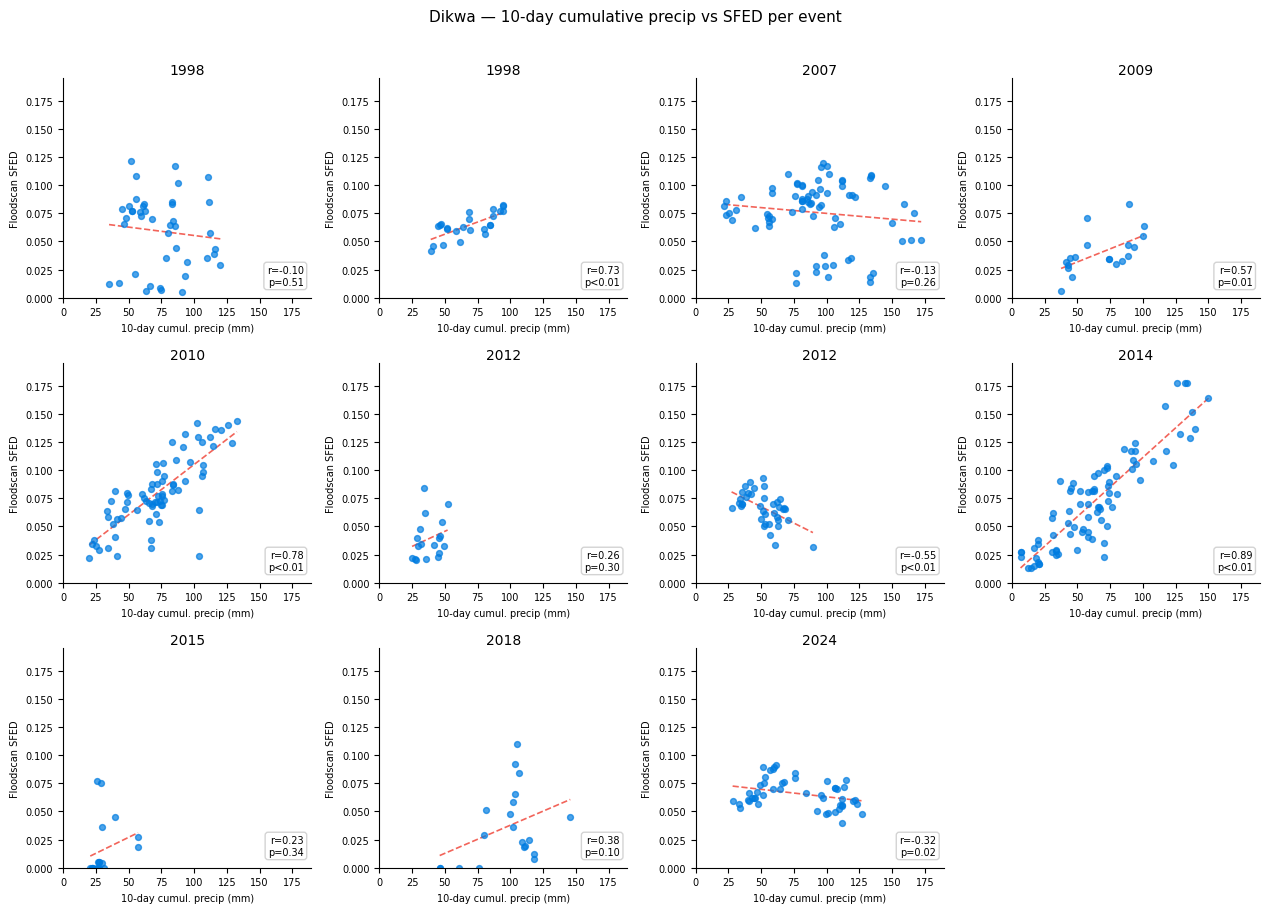

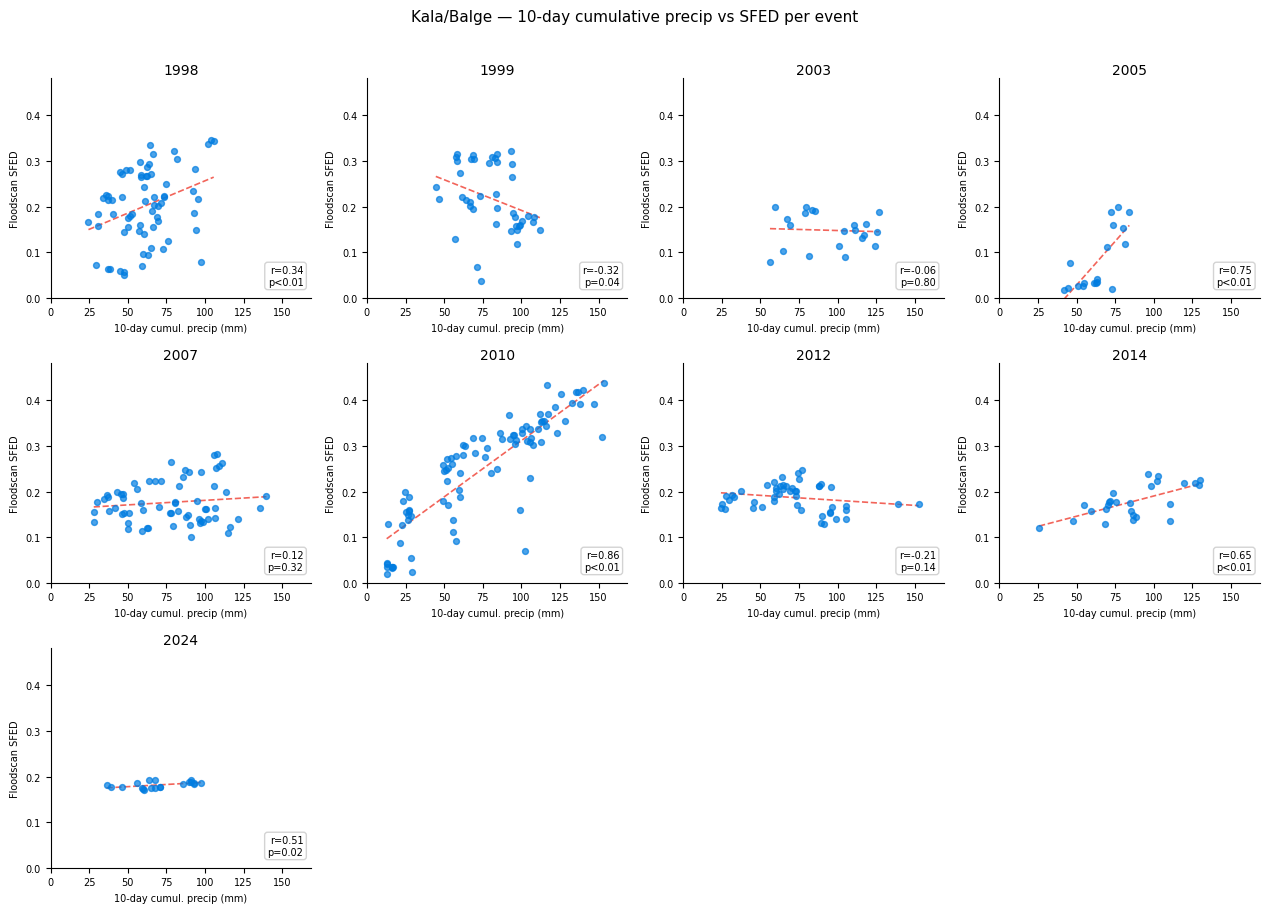

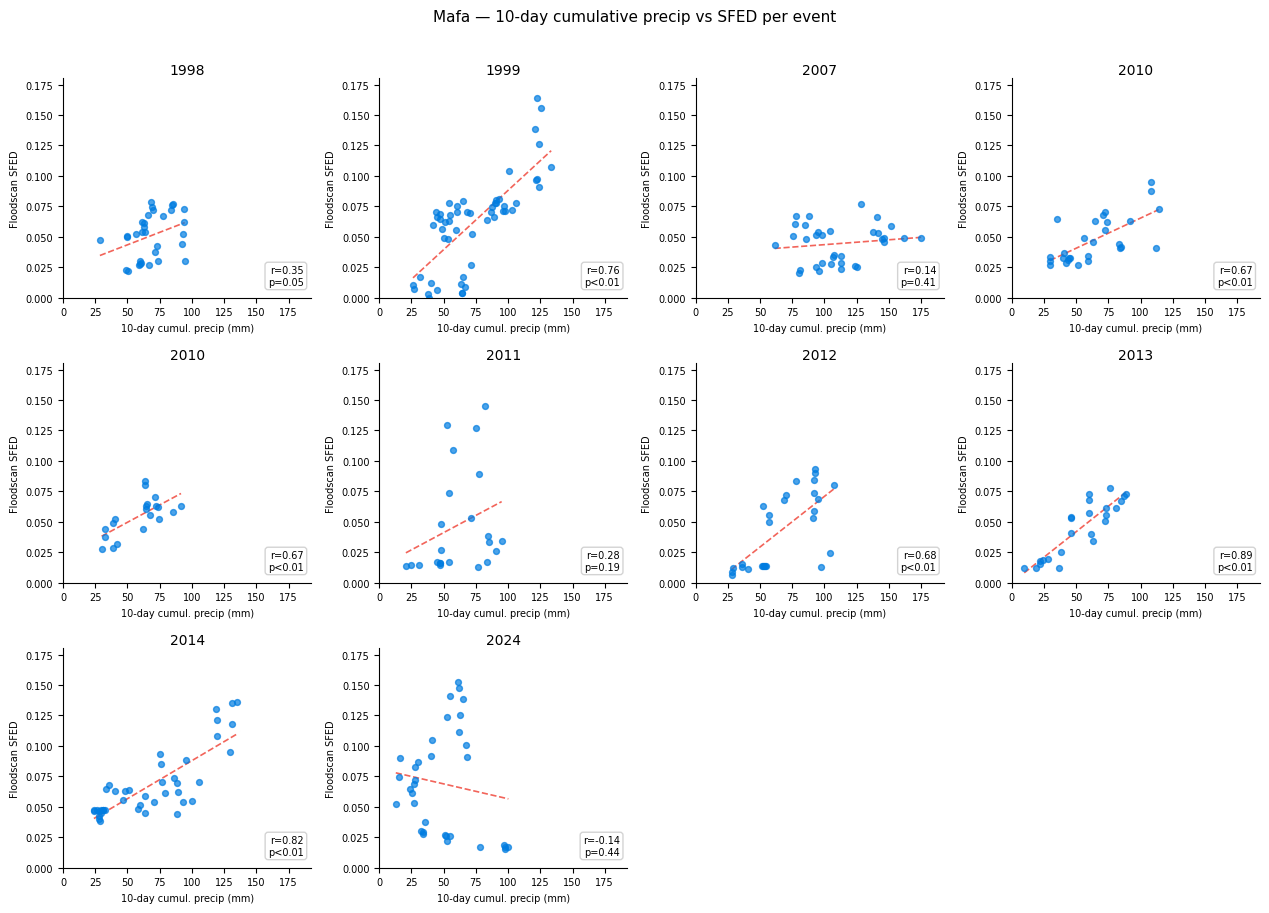

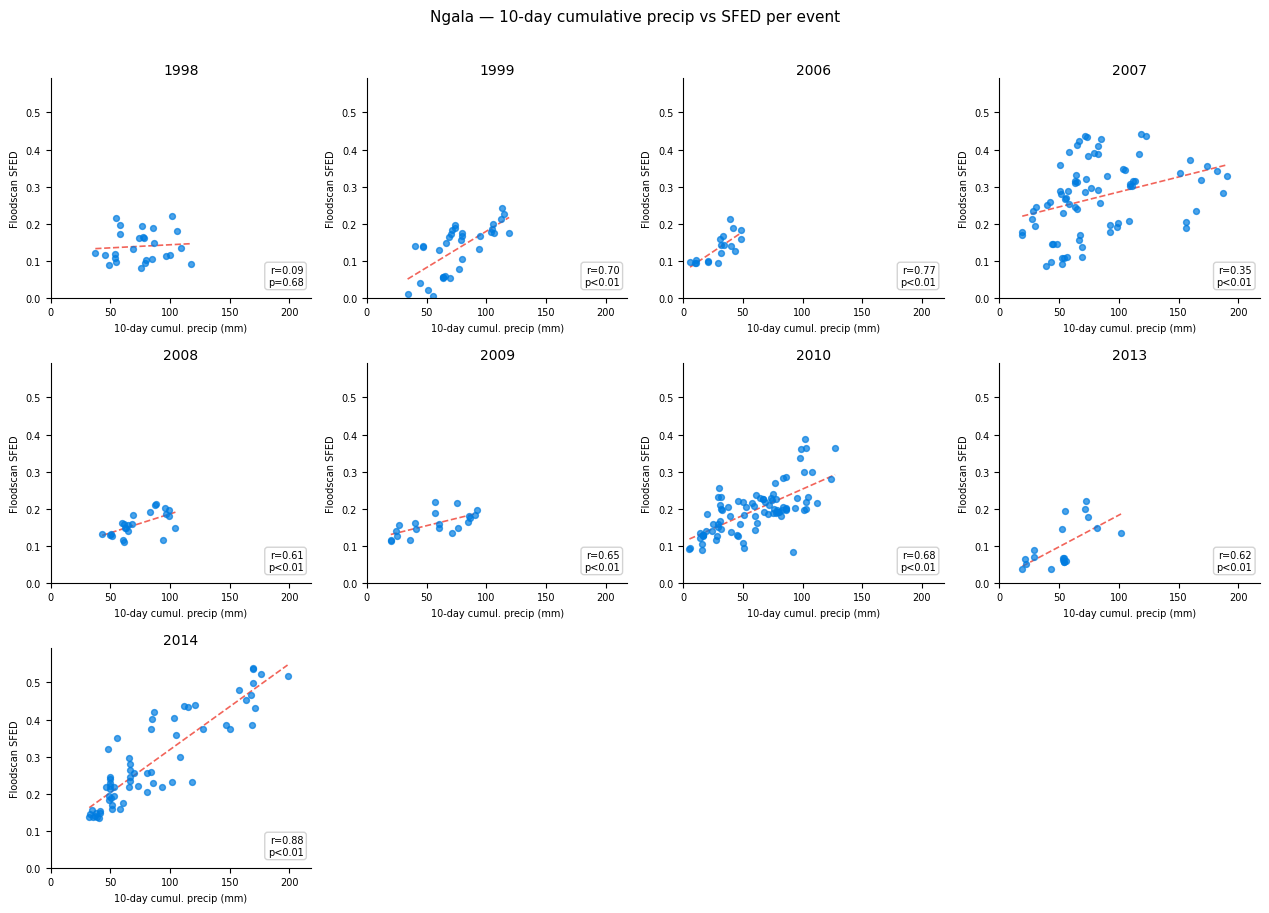

,pcode,lga,mean_r,std_r,n_events
0,NG008025,Ngala,0.595,0.239,9
1,NG008019,Mafa,0.513,0.335,10
2,NG008015,Kala/Balge,0.293,0.431,9
3,NG008008,Dikwa,0.249,0.477,11


In [28]:
from scipy import stats as scipy_stats

event_corrs = []

for pcode in PCODES:
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    ev = df_events[df_events["pcode"] == pcode].reset_index(drop=True)

    if ev.empty:
        continue

    df_sfed_lga = df_fs[df_fs["pcode"] == pcode][["date", "sfed"]].sort_values("date").set_index("date")
    df_prec_lga = df_pr[df_pr["pcode"] == pcode][["date", "precip_10d"]].sort_values("date").set_index("date")

    # Shared axis limits across all events for this LGA
    sfed_xmax, prec_xmax = 0.0, 0.0
    for _, event in ev.iterrows():
        w_start = event["event_start"] - pd.Timedelta(days=PRE_DAYS)
        w_end = event["event_end"] + pd.Timedelta(days=POST_DAYS)
        sfed_win = df_sfed_lga.loc[w_start:w_end, "sfed"]
        prec_win = df_prec_lga.loc[w_start:w_end, "precip_10d"]
        if not sfed_win.empty:
            sfed_xmax = max(sfed_xmax, sfed_win.max())
        if not prec_win.empty and prec_win.notna().any():
            prec_xmax = max(prec_xmax, prec_win.max())
    sfed_xmax *= 1.1
    prec_xmax = max(prec_xmax * 1.1, 1.0)

    n = len(ev)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0), squeeze=False)

    for i, (_, event) in enumerate(ev.iterrows()):
        ax = axes[i // ncols, i % ncols]

        w_start = event["event_start"] - pd.Timedelta(days=PRE_DAYS)
        w_end = event["event_end"] + pd.Timedelta(days=POST_DAYS)

        df_win = pd.DataFrame({
            "sfed": df_sfed_lga.loc[w_start:w_end, "sfed"],
            "precip_10d": df_prec_lga.loc[w_start:w_end, "precip_10d"],
        }).dropna()

        if len(df_win) >= 3:
            r, p = scipy_stats.pearsonr(df_win["precip_10d"], df_win["sfed"])
            m, b, _, _, _ = scipy_stats.linregress(df_win["precip_10d"], df_win["sfed"])
            x_line = np.linspace(df_win["precip_10d"].min(), df_win["precip_10d"].max(), 100)
            ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.2, linestyle="--", zorder=1)
            p_str = "p<0.01" if p < 0.01 else f"p={p:.2f}"
            ax.text(0.97, 0.05, f"r={r:.2f}\n{p_str}", transform=ax.transAxes,
                    ha="right", va="bottom", fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.85))
        else:
            r, p = np.nan, np.nan

        event_corrs.append({"pcode": pcode, "lga": lga, "year": event["year"], "r": r, "p": p})

        ax.scatter(df_win["precip_10d"], df_win["sfed"], color="#007CE0", s=18, alpha=0.7, zorder=2)
        ax.set_xlim(0, prec_xmax)
        ax.set_ylim(0, sfed_xmax)
        ax.set_title(str(event["year"]), fontsize=10, pad=3)
        ax.set_xlabel("10-day cumul. precip (mm)", fontsize=7)
        ax.set_ylabel("Floodscan SFED", fontsize=7)
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].set_visible(False)

    fig.suptitle(f"{lga} — 10-day cumulative precip vs SFED per event", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

# Summary table: mean r and std dev per LGA
df_corr_summary = (
    pd.DataFrame(event_corrs)
    .groupby(["pcode", "lga"])["r"]
    .agg(mean_r="mean", std_r="std", n_events="count")
    .reset_index()
    .sort_values("mean_r", ascending=False)
    .reset_index(drop=True)
)
df_corr_summary["mean_r"] = df_corr_summary["mean_r"].round(3)
df_corr_summary["std_r"] = df_corr_summary["std_r"].round(3)
df_corr_summary


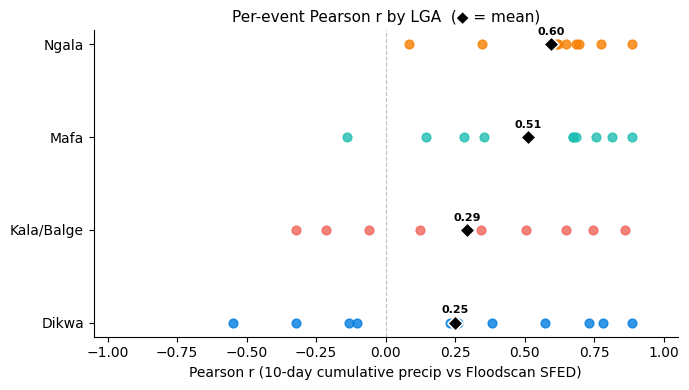

In [29]:
df_event_corrs = pd.DataFrame(event_corrs).dropna(subset=["r"])

lga_names = [gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == p, "ADM2_EN"].iloc[0] for p in PCODES]

fig, ax = plt.subplots(figsize=(7, 4))

for i, (pcode, color) in enumerate(zip(PCODES, LGA_COLORS)):
    sub = df_event_corrs[df_event_corrs["pcode"] == pcode].sort_values("r")

    # Individual event dots
    ax.scatter(sub["r"], [i] * len(sub), color=color, s=40, zorder=3, alpha=0.8)

    # Year labels above each dot
    # for _, row in sub.iterrows():
    #     ax.text(row["r"], i + 0.08, str(int(row["year"])),
    #             ha="center", va="bottom", fontsize=8, color=color)

    # Mean marker (diamond) with value label
    mean_r = sub["r"].mean()
    ax.scatter(mean_r, i, color="black", s=60, marker="D",
               zorder=4, edgecolors="white", linewidth=1.2)
    ax.text(mean_r, i + 0.08, f"{mean_r:.2f}",
            ha="center", va="bottom", fontsize=8, color="black", fontweight="bold")

ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_yticks(range(len(PCODES)))
ax.set_yticklabels(lga_names, fontsize=10)
ax.set_xlabel("Pearson r (10-day cumulative precip vs Floodscan SFED)", fontsize=10)
ax.set_xlim(-1.05, 1.05)
ax.set_title("Per-event Pearson r by LGA  (◆ = mean)", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/event_correlation_summary.png", dpi=300)

## Forecast skill metrics — RP-3 threshold

For each LGA and year, compare the seasonal maximum Floodscan SFED against the SFED RP-3 threshold (flood / no flood) and the maximum 10-day cumulative IMERG in a window spanning **14 days before to 7 days after event onset** against the IMERG RP-3 threshold (trigger fired / not). In flood years with multiple events, the trigger fires if the window of ANY event exceeds the threshold. In non-flood years (no anchor event), the seasonal maximum IMERG is used.

In [30]:
FLOOD_MONTHS = range(6, 12)  # June–November
PRE_DAYS  = 14  # days before event onset
POST_DAYS =  7  # days after event onset

# Seasonal max SFED per LGA per year — flood definition
df_fs_season = df_fs[
    (df_fs["date"].dt.month.isin(FLOOD_MONTHS)) &
    (df_fs["date"].dt.year < 2026)
].copy()
df_fs_season["year"] = df_fs_season["date"].dt.year
sfed_yr_max = df_fs_season.groupby(["pcode", "year"])["sfed"].max().to_dict()

# Seasonal max IMERG per LGA per year — used for non-flood years (no event anchor)
df_pr_season = df_pr[
    (df_pr["date"].dt.month.isin(FLOOD_MONTHS)) &
    (df_pr["date"].dt.year < 2026)
].copy()
df_pr_season["year"] = df_pr_season["date"].dt.year
pr_yr_max = df_pr_season.groupby(["pcode", "year"])["precip_10d"].max().to_dict()

# Event-window IMERG: max precip_10d in [onset - PRE_DAYS, onset + POST_DAYS].
# For years with multiple events, take the max across all event windows.
pr_event_max = {}
for pcode in PCODES:
    for yr, ev_yr in df_events[df_events["pcode"] == pcode].groupby("year"):
        window_maxes = []
        for _, ev in ev_yr.iterrows():
            w_start = ev["event_start"] - pd.Timedelta(days=PRE_DAYS)
            w_end   = ev["event_start"] + pd.Timedelta(days=POST_DAYS)
            win = df_pr[
                (df_pr["pcode"] == pcode) &
                (df_pr["date"] >= w_start) &
                (df_pr["date"] <= w_end)
            ]["precip_10d"]
            window_maxes.append(win.max() if not win.empty else np.nan)
        pr_event_max[(pcode, yr)] = float(np.nanmax(window_maxes)) if window_maxes else np.nan

all_years = sorted(set(df_fs_season["year"].unique()) | set(df_pr_season["year"].unique()))

CAT_COLORS = {
    "hit":              "#1EBFB3",
    "miss":             "#F77F00",
    "false_alarm":      "#F2645A",
    "correct_negative": "#CCCCCC",
}
CAT_LABELS = {
    "hit":              "Hit",
    "miss":             "Miss",
    "false_alarm":      "False alarm",
    "correct_negative": "Correct negative",
}

det_records = []
for pcode in PCODES:
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    thresh       = thresholds[pcode]
    imerg_thresh = pr_thresholds_rp3[pcode]

    for yr in all_years:
        sfed_max = float(sfed_yr_max.get((pcode, yr), 0) or 0)
        flood    = sfed_max >= thresh

        if flood:
            imerg_max = float(pr_event_max.get((pcode, yr), 0) or 0)
        else:
            imerg_max = float(pr_yr_max.get((pcode, yr), 0) or 0)

        trigger = imerg_max >= imerg_thresh

        if   flood and trigger:     cat = "hit"
        elif flood and not trigger: cat = "miss"
        elif not flood and trigger: cat = "false_alarm"
        else:                       cat = "correct_negative"

        det_records.append({
            "pcode": pcode, "lga": lga, "year": yr,
            "sfed_norm":  sfed_max  / thresh       if thresh       > 0 else 0,
            "imerg_norm": imerg_max / imerg_thresh if imerg_thresh > 0 else 0,
            "category": cat,
        })

df_det = pd.DataFrame(det_records)

# POD and FAR per LGA
pod_far_records = []
for pcode in PCODES:
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    sub = df_det[df_det["pcode"] == pcode]
    H  = (sub["category"] == "hit").sum()
    M  = (sub["category"] == "miss").sum()
    FA = (sub["category"] == "false_alarm").sum()
    pod = H / (H + M)  if (H + M)  > 0 else np.nan
    far = FA / (H + FA) if (H + FA) > 0 else np.nan
    pod_far_records.append({"lga": lga, "hits": H, "misses": M, "false_alarms": FA,
                             "pod": round(pod, 2), "far": round(far, 2)})

df_pod_far = pd.DataFrame(pod_far_records)
df_pod_far

,lga,hits,misses,false_alarms,pod,far
0,Dikwa,2,7,5,0.22,0.71
1,Kala/Balge,1,8,7,0.11,0.88
2,Mafa,2,7,6,0.22,0.75
3,Ngala,1,8,6,0.11,0.86


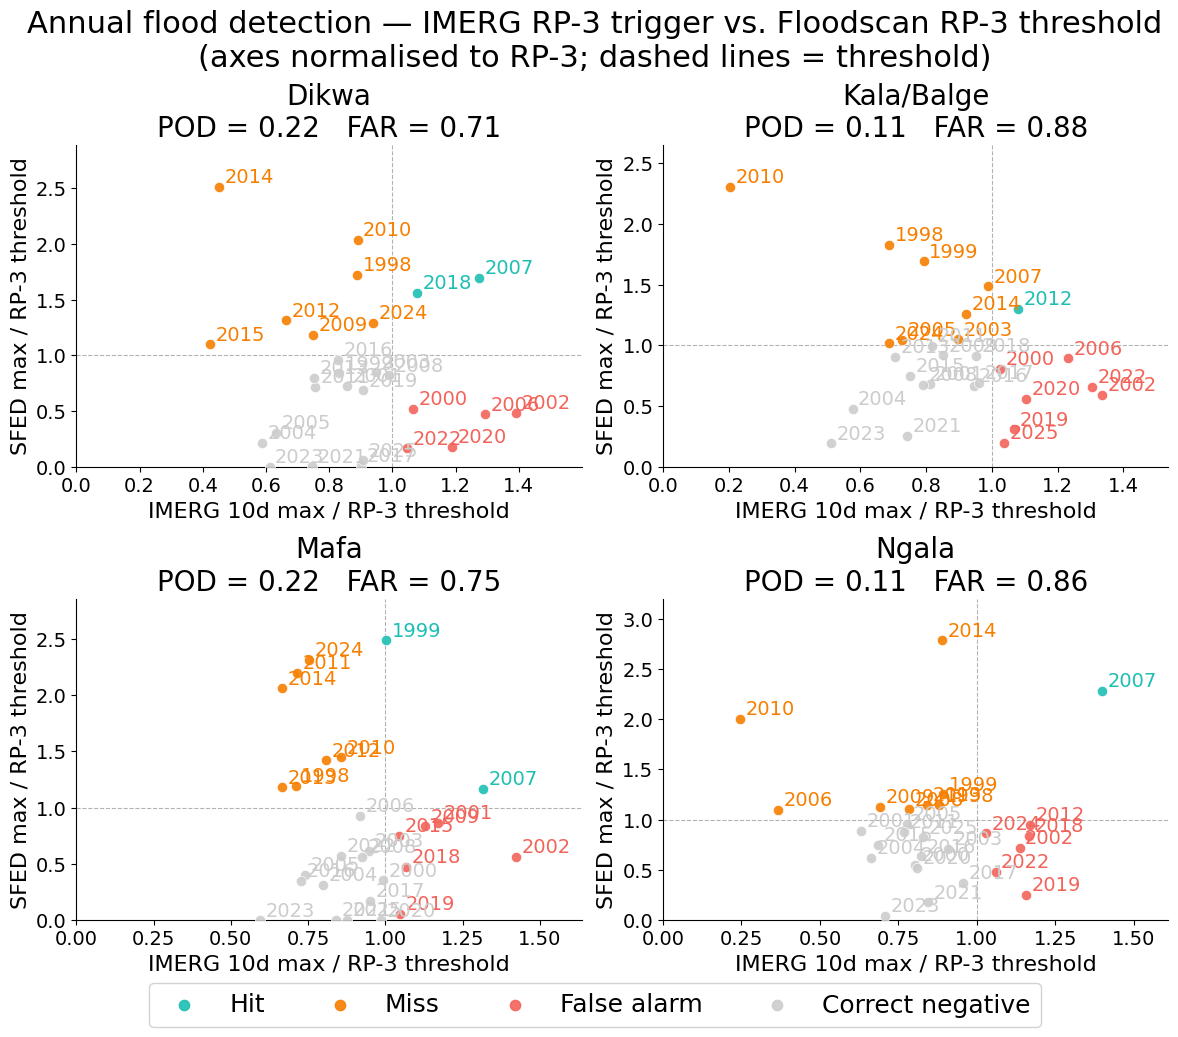

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), squeeze=False)

for ax, pcode in zip(axes.flatten(), PCODES):
    lga = gdf_lga_sel.loc[gdf_lga_sel["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    sub = df_det[df_det["pcode"] == pcode]

    for cat, color in CAT_COLORS.items():
        pts = sub[sub["category"] == cat]
        if pts.empty:
            continue
        ax.scatter(pts["imerg_norm"], pts["sfed_norm"], color=color, s=55, zorder=3,
                   alpha=0.9, edgecolors="white", linewidth=0.5, label=CAT_LABELS[cat])
        for _, row in pts.iterrows():
            ax.annotate(str(int(row["year"])), (row["imerg_norm"], row["sfed_norm"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=14, color=color)

    ax.axvline(1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axhline(1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

    xmax = max(sub["imerg_norm"].max() * 1.15, 1.3)
    ymax = max(sub["sfed_norm"].max() * 1.15, 1.3)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)

    row_summary = df_pod_far[df_pod_far["lga"] == lga].iloc[0]
    ax.set_title(f"{lga}\nPOD = {row_summary['pod']:.2f}   FAR = {row_summary['far']:.2f}", fontsize=20)
    ax.set_xlabel("IMERG 10d max / RP-3 threshold", fontsize=16)
    ax.set_ylabel("SFED max / RP-3 threshold", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.spines[["top", "right"]].set_visible(False)

handles = [
    plt.scatter([], [], color=c, s=55, alpha=0.9, label=CAT_LABELS[cat])
    for cat, c in CAT_COLORS.items()
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=18,
           framealpha=0.85, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(
    "Annual flood detection — IMERG RP-3 trigger vs. Floodscan RP-3 threshold\n"
    "(axes normalised to RP-3; dashed lines = threshold)",
    fontsize=22,
)
plt.tight_layout()
plt.savefig("figures/pod_far_scatter.png", dpi=300, bbox_inches="tight")
plt.show()